In [229]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train_path = r"C:\Users\divye\Data_science_projects\spaceship_titanic\data\train.csv"

train_df = pd.read_csv(train_path)
train_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [230]:
train_df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [231]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [232]:
train_df.isna().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [233]:
train_df['Group'] = train_df['PassengerId'].str.split('_').str[0]
missing_homeplanet = train_df[train_df['HomePlanet'].isna()]

missing_groups = missing_homeplanet['Group'].unique()
train_df[train_df['Group'].isin(missing_groups)].sort_values('Group')

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Group
58,0064_01,Mars,True,F/14/S,TRAPPIST-1e,15.0,False,0.0,0.0,0.0,0.0,0.0,NaN,True,0064
59,0064_02,NaN,True,E/3/S,TRAPPIST-1e,33.0,False,0.0,0.0,NaN,0.0,0.0,Colatz Keen,True,0064
113,0119_01,NaN,False,A/0/P,TRAPPIST-1e,39.0,False,0.0,2344.0,0.0,65.0,6898.0,Batan Coning,False,0119
114,0119_02,Europa,True,A/0/P,TRAPPIST-1e,13.0,False,0.0,0.0,0.0,0.0,0.0,Kleeiak Coning,True,0119
186,0210_01,NaN,True,D/6/P,55 Cancri e,24.0,False,0.0,0.0,NaN,0.0,0.0,Arraid Inicont,True,0210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8614,9194_02,Europa,False,E/603/S,TRAPPIST-1e,32.0,True,1003.0,909.0,0.0,0.0,15.0,Tachba Subwor,False,9194
8613,9194_01,NaN,False,E/603/S,55 Cancri e,53.0,False,0.0,4017.0,0.0,13.0,3147.0,NaN,False,9194
8666,9248_01,NaN,False,F/1792/S,55 Cancri e,38.0,NaN,28.0,1208.0,973.0,207.0,0.0,Gian Perle,True,9248
8674,9257_01,NaN,False,F/1892/P,TRAPPIST-1e,13.0,False,39.0,0.0,1085.0,24.0,0.0,Ties Apple,False,9257


In [234]:
train_df['HomePlanet'] = train_df.groupby('Group')['HomePlanet'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x)
)
train_df[['Deck', 'CabinNum', 'Side']] = train_df['Cabin'].str.split('/', expand=True)

deck_homeplanet = train_df.groupby(['Deck', 'HomePlanet']).size().unstack(fill_value=0)
print(deck_homeplanet)
pd.crosstab(train_df['Deck'], train_df['HomePlanet'], normalize='index')

HomePlanet  Earth  Europa  Mars
Deck                           
A               0     255     0
B               0     778     0
C               0     743     0
D               0     189   285
E             400     130   335
F            1620       0  1130
G            2518       0     0
T               0       4     0


HomePlanet,Earth,Europa,Mars
Deck,,,
A,0.000000,1.000000,0.000000
B,0.000000,1.000000,0.000000
C,0.000000,1.000000,0.000000
D,0.000000,0.398734,0.601266
E,0.462428,0.150289,0.387283
F,0.589091,0.000000,0.410909
G,1.000000,0.000000,0.000000
T,0.000000,1.000000,0.000000


In [235]:
def fill_strong_decks(row):
    if pd.isna(row['HomePlanet']):
        if row['Deck'] in ['A', 'B', 'C', 'T']:
            return 'Europa'
        elif row['Deck'] == 'G':
            return 'Earth'
    return row['HomePlanet']

train_df['HomePlanet'] = train_df.apply(fill_strong_decks, axis=1)


train_df[train_df['Group'].isin(missing_groups)].sort_values('Group')



,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Group,Deck,CabinNum,Side
58,0064_01,Mars,True,F/14/S,TRAPPIST-1e,15.0,False,0.0,0.0,0.0,0.0,0.0,NaN,True,0064,F,14,S
59,0064_02,Mars,True,E/3/S,TRAPPIST-1e,33.0,False,0.0,0.0,NaN,0.0,0.0,Colatz Keen,True,0064,E,3,S
113,0119_01,Europa,False,A/0/P,TRAPPIST-1e,39.0,False,0.0,2344.0,0.0,65.0,6898.0,Batan Coning,False,0119,A,0,P
114,0119_02,Europa,True,A/0/P,TRAPPIST-1e,13.0,False,0.0,0.0,0.0,0.0,0.0,Kleeiak Coning,True,0119,A,0,P
186,0210_01,NaN,True,D/6/P,55 Cancri e,24.0,False,0.0,0.0,NaN,0.0,0.0,Arraid Inicont,True,0210,D,6,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8614,9194_02,Europa,False,E/603/S,TRAPPIST-1e,32.0,True,1003.0,909.0,0.0,0.0,15.0,Tachba Subwor,False,9194,E,603,S
8613,9194_01,Europa,False,E/603/S,55 Cancri e,53.0,False,0.0,4017.0,0.0,13.0,3147.0,NaN,False,9194,E,603,S
8666,9248_01,NaN,False,F/1792/S,55 Cancri e,38.0,NaN,28.0,1208.0,973.0,207.0,0.0,Gian Perle,True,9248,F,1792,S
8674,9257_01,NaN,False,F/1892/P,TRAPPIST-1e,13.0,False,39.0,0.0,1085.0,24.0,0.0,Ties Apple,False,9257,F,1892,P


In [236]:
train_df['HomePlanet'] = train_df.groupby('Deck')['HomePlanet'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x)
)

train_df[train_df['Group'].isin(missing_groups)].sort_values('Group')
train_df['HomePlanet'].isna().sum()

199

In [237]:
cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Create total spending (if not already)
train_df['TotalSpend'] = train_df[cols].sum(axis=1)

# Fill CryoSleep based on spending
train_df.loc[(train_df['CryoSleep'].isna()) & (train_df['TotalSpend'] == 0), 'CryoSleep'] = True
train_df.loc[(train_df['CryoSleep'].isna()) & (train_df['TotalSpend'] > 0), 'CryoSleep'] = False



In [238]:
pd.crosstab(train_df['HomePlanet'], train_df['Destination'])

Destination,55 Cancri e,PSO J318.5-22,TRAPPIST-1e
HomePlanet,,,
Earth,688,711,3134
Europa,868,18,1183
Mars,194,49,1471


In [239]:
# Step 1: Create mapping safely (ignore NaNs in HomePlanet)
dest_to_planet = train_df.dropna(subset=['HomePlanet']) \
                   .groupby('Destination')['HomePlanet'] \
                   .agg(lambda x: x.value_counts().index[0])

# Step 2: Fill only where BOTH conditions are valid
train_df['HomePlanet'] = train_df.apply(
    lambda row: dest_to_planet[row['Destination']]
    if pd.isna(row['HomePlanet']) and pd.notna(row['Destination']) and row['Destination'] in dest_to_planet
    else row['HomePlanet'],
    axis=1
)
train_df['HomePlanet'].isna().sum()
train_df['HomePlanet'].fillna(train_df['HomePlanet'].mode()[0], inplace=True)
train_df.isnull().sum()


PassengerId       0
HomePlanet        0
CryoSleep         0
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
Group             0
Deck            199
CabinNum        199
Side            199
TotalSpend        0
dtype: int64

In [240]:
train_df['Deck'] = train_df.groupby('Group')['Deck'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x)
)
train_df['Side'] = train_df.groupby('Group')['Side'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x)
)
train_df[['Deck', 'Side']].isnull().sum()



Deck    99
Side    99
dtype: int64

In [241]:
train_df['Deck'] = train_df.groupby('HomePlanet')['Deck'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x)
)
train_df[['Deck', 'Side']].isnull().sum()

Deck     0
Side    99
dtype: int64

In [242]:
pd.crosstab(train_df['Destination'], train_df['HomePlanet'], normalize='index')

HomePlanet,Earth,Europa,Mars
Destination,,,
55 Cancri e,0.382222,0.510000,0.107778
PSO J318.5-22,0.915829,0.022613,0.061558
TRAPPIST-1e,0.551310,0.200000,0.248690


In [243]:
train_df['Side'].fillna(train_df['Side'].mode()[0], inplace=True)

train_df['Side'].isna().sum()

0

In [244]:
home_to_dest = train_df.groupby('HomePlanet')['Destination'] \
    .agg(lambda x: x.value_counts().index[0])

train_df.loc[train_df['Destination'].isna(), 'Destination'] = \
    train_df.loc[train_df['Destination'].isna(), 'HomePlanet'].map(home_to_dest)
train_df.isna().sum()

PassengerId       0
HomePlanet        0
CryoSleep         0
Cabin           199
Destination       0
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
Group             0
Deck              0
CabinNum        199
Side              0
TotalSpend        0
dtype: int64

In [245]:
train_df['Age'] = train_df.groupby(['HomePlanet', 'CryoSleep'])['Age'].transform(
    lambda x: x.fillna(x.median())
)
train_df['Age'].isna().sum()

0

In [246]:
train_df.loc[train_df['VIP'].isna() & (train_df['TotalSpend'] > train_df['TotalSpend'].median()), 'VIP'] = True
train_df.loc[train_df['VIP'].isna() & (train_df['TotalSpend'] <= train_df['TotalSpend'].median()), 'VIP'] = False

train_df.isna().sum()

PassengerId       0
HomePlanet        0
CryoSleep         0
Cabin           199
Destination       0
Age               0
VIP               0
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
Group             0
Deck              0
CabinNum        199
Side              0
TotalSpend        0
dtype: int64

In [247]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in spend_cols:
    train_df[col].fillna(0, inplace=True)

train_df.loc[train_df['CryoSleep'] == True, spend_cols] = 0

In [248]:
train_df[(train_df['CryoSleep'] == True) & (train_df[['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']].sum(axis=1) != 0)]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Group,Deck,CabinNum,Side,TotalSpend


In [249]:
train_df[train_df['VIP'] == True][['TotalSpend']].describe()

,TotalSpend
count,296.000000
mean,3870.300676
std,4729.688935
min,0.000000
25%,992.250000
50%,2140.000000
75%,4853.000000
max,31076.000000


In [250]:
train_df[train_df['VIP'] == False][['TotalSpend']].describe()

,TotalSpend
count,8397.000000
mean,1355.227105
std,2670.704887
min,0.000000
25%,0.000000
50%,702.000000
75%,1346.000000
max,35987.000000


In [251]:

train_df[train_df['Age'] == 0][['PassengerId','HomePlanet','CryoSleep','VIP','Transported']]

train_df[train_df['Age'] == 0]['CryoSleep'].value_counts()
train_df.loc[train_df['Age'] == 0, 'Age'] = None

train_df['Age'] = train_df.groupby(['HomePlanet', 'CryoSleep'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

train_df['Age'].describe()

count    8693.000000
mean       29.276487
std        13.766277
min         1.000000
25%        20.000000
50%        27.000000
75%        37.000000
max        79.000000
Name: Age, dtype: float64

In [252]:
train_df[train_df['Age'] == 1]['CryoSleep'].value_counts()

True     44
False    23
Name: CryoSleep, dtype: int64

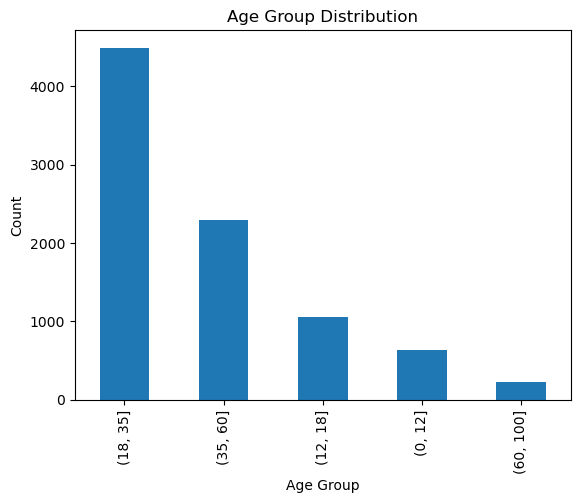

In [253]:
train_df['AgeGroup'] = pd.cut(train_df['Age'], bins=[0,12,18,35,60,100])
train_df['AgeGroup'].value_counts().plot(kind='bar')
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

In [254]:
pd.crosstab(train_df['Destination'], train_df['HomePlanet'], normalize='index')

HomePlanet,Earth,Europa,Mars
Destination,,,
55 Cancri e,0.382222,0.510000,0.107778
PSO J318.5-22,0.915829,0.022613,0.061558
TRAPPIST-1e,0.552075,0.200098,0.247827


In [255]:
pd.crosstab(train_df['Deck'], train_df['HomePlanet'], normalize='index')

HomePlanet,Earth,Europa,Mars
Deck,,,
A,0.003817,0.996183,0.000000
B,0.008589,0.991411,0.000000
C,0.011827,0.988173,0.000000
D,0.014374,0.392197,0.593429
E,0.473446,0.148023,0.378531
F,0.597509,0.000356,0.402135
G,0.997376,0.002624,0.000000
T,0.000000,1.000000,0.000000


In [256]:
cleaned_train__df = train_df[[
    'PassengerId',
    'HomePlanet',
    'Destination',
    'Age',
    'VIP',
    'CryoSleep',
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck',
    'Deck',
    'Side',
    'TotalSpend',
    'Transported'
]]

cleaned_train__df.head()

,PassengerId,HomePlanet,Destination,Age,VIP,CryoSleep,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Deck,Side,TotalSpend,Transported
0,0001_01,Europa,TRAPPIST-1e,39.0,False,False,0.0,0.0,0.0,0.0,0.0,B,P,0.0,False
1,0002_01,Earth,TRAPPIST-1e,24.0,False,False,109.0,9.0,25.0,549.0,44.0,F,S,736.0,True
2,0003_01,Europa,TRAPPIST-1e,58.0,True,False,43.0,3576.0,0.0,6715.0,49.0,A,S,10383.0,False
3,0003_02,Europa,TRAPPIST-1e,33.0,False,False,0.0,1283.0,371.0,3329.0,193.0,A,S,5176.0,False
4,0004_01,Earth,TRAPPIST-1e,16.0,False,False,303.0,70.0,151.0,565.0,2.0,F,S,1091.0,True


In [257]:
cleaned_train__df.isna().sum()

PassengerId     0
HomePlanet      0
Destination     0
Age             0
VIP             0
CryoSleep       0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Deck            0
Side            0
TotalSpend      0
Transported     0
dtype: int64